# Clustering — Exercise 7: A Generative Model with Gaussian Mixtures

**Course:** Introduction to Machine Learning and Applied Artificial Intelligence
**Institution:** High School of Digital Culture, ITMO University


<a href="https://colab.research.google.com/github/Mir-robotics/ITMO-Introduction-to-Machine-Learning-and-Applied-Artificial-Intelligence/blob/main/Clustering%202/Clustering_Exercise_7.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


A **Gaussian Mixture Model (GMM)** is a natural generalization of K-means: instead of
assigning each point to the single nearest centroid, a GMM models the data as a
mixture of several multivariate normal ("Gaussian") distributions, each with its own
mean *and* covariance (shape). Because a GMM models a full probability density rather
than just cluster centers, it can do something K-means fundamentally can't: **generate
new, synthetic data points** by sampling from the fitted distribution.

In this notebook we fit a GMM to handwritten digit images and use it to generate new,
synthetic digit images.


## 0. Setup and data loading

We use the small `load_digits` dataset (8×8 images, a lighter-weight cousin of MNIST)
since a full covariance-matrix GMM is computationally expensive, and this exercise
will already involve fitting dozens of GMM models during hyperparameter search.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

digits = load_digits()
print(f"digits.data.shape: {digits.data.shape}")


digits.data.shape: (1797, 64)


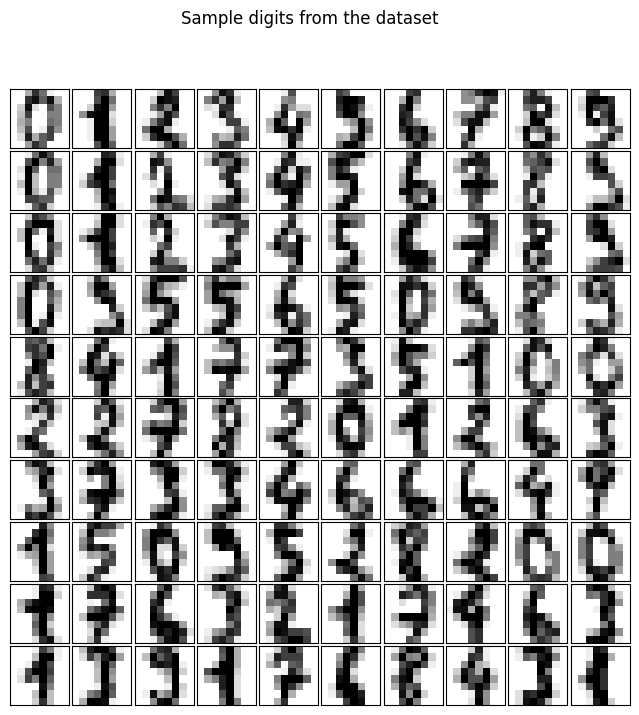

In [2]:
fig, ax = plt.subplots(10, 10, figsize=(8, 8), subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i, axi in enumerate(ax.flat):
    im = axi.imshow(digits.data[i].reshape(8, 8), cmap="binary")
    im.set_clim(0, 16)
plt.suptitle("Sample digits from the dataset")
plt.show()


## 1. Dimensionality reduction with PCA

Fitting a full-covariance GMM directly on 64 raw pixel dimensions would be slow and
prone to overfitting (a full covariance matrix has $O(d^2)$ parameters per
component). We first reduce dimensionality with PCA, keeping just enough components
to retain 99% of the variance.


In [3]:
pca = PCA(n_components=0.99, svd_solver="full")
digits_pca = pca.fit_transform(digits.data)

print(f"Number of principal components retained (99% variance): {pca.n_components_}")


Number of principal components retained (99% variance): 41


## 2. Choosing the number of GMM components with AIC

Unlike K-means's $k$, a GMM's number of components isn't something we should just
guess — too few components will underfit the data's structure, while too many will
overfit and start modeling noise. We use the **Akaike Information Criterion (AIC)** —
a metric that balances model fit against model complexity — to select the number of
components objectively, trying values from 50 to 240 in steps of 10 and picking
whichever gives the lowest (best) AIC.


In [4]:
aic_by_n_components = {}
for n in range(50, 250, 10):
    gm = GaussianMixture(n_components=n, covariance_type="full", random_state=29).fit(digits_pca)
    aic_by_n_components[n] = gm.aic(digits_pca)


Best number of components by AIC: 170


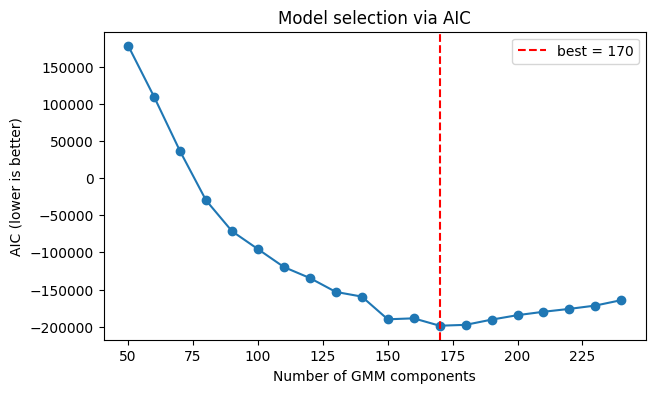

In [5]:
best_n_components = min(aic_by_n_components, key=aic_by_n_components.get)
print(f"Best number of components by AIC: {best_n_components}")

plt.figure(figsize=(7, 4))
plt.plot(list(aic_by_n_components.keys()), list(aic_by_n_components.values()), marker="o")
plt.axvline(best_n_components, color="red", linestyle="--", label=f"best = {best_n_components}")
plt.xlabel("Number of GMM components")
plt.ylabel("AIC (lower is better)")
plt.legend()
plt.title("Model selection via AIC")
plt.show()


## 3. Fit the final model

We train the final Gaussian Mixture with the AIC-selected number of components, and
check the `.converged_` flag to confirm the EM (expectation-maximization) fitting
algorithm actually reached a stable solution rather than hitting its iteration limit.


In [6]:
gm_final = GaussianMixture(
    n_components=best_n_components, covariance_type="full", random_state=29
).fit(digits_pca)

print(f"Converged: {gm_final.converged_}")


Converged: True


## 4. Generate new, synthetic digits

This is the payoff of using a *generative* model: `.sample()` draws brand-new points
from the fitted probability distribution — points that were never in the original
dataset, but that "look like" they could have been, statistically speaking.


In [7]:
new_samples, new_sample_component_labels = gm_final.sample(100)

# Sample mean of the first PCA coordinate across the 100 generated points
first_coord_mean = round(np.mean(new_samples[:, 0]), 3)
print(f"Sample mean of coordinate 0 across generated objects: {first_coord_mean}")


Sample mean of coordinate 0 across generated objects: 0.288


### Back to image space

The generated points live in PCA space (the reduced coordinate system), so to view
them as images we need to invert the PCA transform and map them back to the original
64-pixel space.


In [8]:
original_space_samples = pca.inverse_transform(new_samples)
print(f"original_space_samples.shape: {original_space_samples.shape}")


original_space_samples.shape: (100, 64)


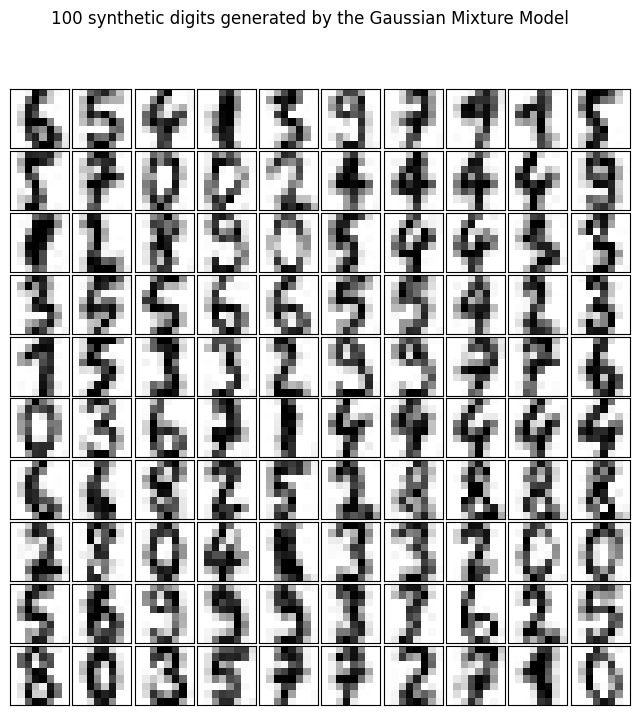

In [9]:
fig, ax = plt.subplots(10, 10, figsize=(8, 8), subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i, axi in enumerate(ax.flat):
    im = axi.imshow(original_space_samples[i].reshape(8, 8), cmap="binary")
    im.set_clim(0, 16)
plt.suptitle("100 synthetic digits generated by the Gaussian Mixture Model")
plt.show()


## Summary

- A Gaussian Mixture Model extends K-means from "assign each point to one of $k$
  centroids" to "model the data as a sum of $k$ probability distributions" — which
  turns clustering into something closer to density estimation.
- Because it models a real probability density, a fitted GMM can be **sampled from**
  to generate new synthetic data — something a plain K-means model has no natural way
  to do.
- The number of components is a genuine hyperparameter that needs tuning; AIC (or
  the related BIC) gives a principled, quantitative way to balance fit quality against
  model complexity, rather than picking a number by eye.
- PCA plays a supporting role here: reducing to the principal components most of the
  original variance made fitting a full-covariance GMM computationally tractable, and
  `pca.inverse_transform()` let us map generated points back into a space we can
  actually visualize as images.
